In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('StudentsPerformance.csv')

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
np.random.seed(42)
df['Science Score']=np.random.randint(-20,130,size=len(df))

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score
0,female,group B,bachelor's degree,standard,none,72,72,74,82
1,female,group C,some college,standard,completed,69,90,88,72
2,female,group B,master's degree,standard,none,90,95,93,-6
3,male,group A,associate's degree,free/reduced,none,47,57,44,86
4,male,group C,some college,standard,none,76,78,75,51


In [ ]:
df.loc[df.sample(frac=0.1).index,"Science Score"]=np.nan

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
Science Score,100


In [ ]:
df["Science Score"]=df["Science Score"].ffill()
df["Science Score"]=df["Science Score"].bfill()

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
Science Score,0


In [ ]:
int((df["Science Score"]<0).sum()),int((df["Science Score"]>100).sum())

(128, 203)

In [ ]:
med=df["Science Score"].median()
df["Science Score"]=df["Science Score"].where(df["Science Score"].between(0,100),med)

In [ ]:
int((df["Science Score"]<0).sum()),int((df["Science Score"]>100).sum())

(0, 0)

In [ ]:
df["CGPA"]=(
    df['Science Score']
    +df['math score']
    +df['reading score']
    +df['writing score'])/400 *10

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score,CGPA
0,female,group B,bachelor's degree,standard,none,72,72,74,82.0,7.500
1,female,group C,some college,standard,completed,69,90,88,72.0,7.975
2,female,group B,master's degree,standard,none,90,95,93,54.0,8.300
3,male,group A,associate's degree,free/reduced,none,47,57,44,86.0,5.850
4,male,group C,some college,standard,none,76,78,75,51.0,7.000


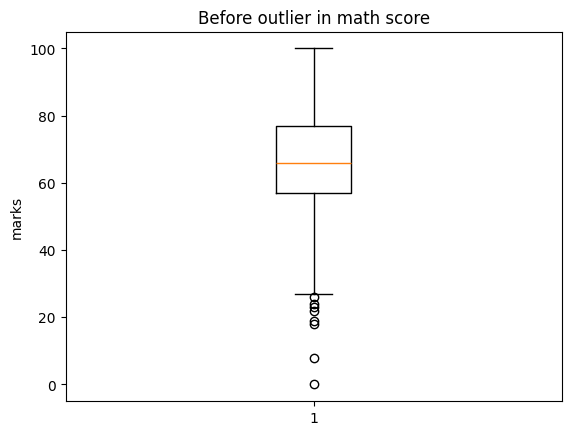

In [ ]:
plt.boxplot(df["math score"])
plt.title("Before outlier in math score")
plt.ylabel("marks")
plt.show()

In [ ]:
Q1=df["math score"].quantile(0.25)
Q3=df["math score"].quantile(0.75)

In [ ]:
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df["math score"]=df["math score"].where(df["math score"]>=lower_bound,lower_bound)
df["math score"]=df["math score"].where(df["math score"]<=upper_bound,upper_bound)

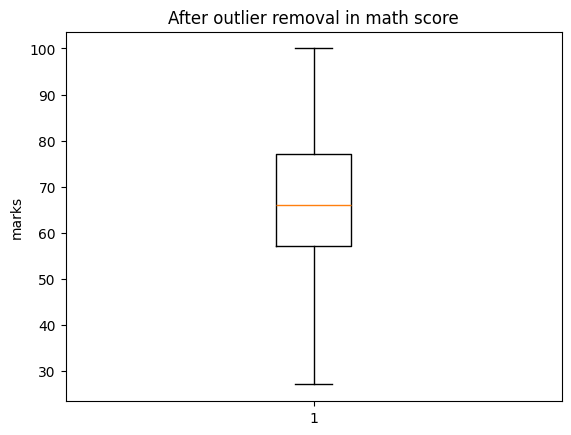

In [ ]:
plt.boxplot(df["math score"])
plt.title("After outlier removal in math score")
plt.ylabel("marks")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["gender"]=le.fit_transform(df["gender"])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Science Score,CGPA
0,0,group B,bachelor's degree,standard,none,72,72,74,82.0,7.500
1,0,group C,some college,standard,completed,69,90,88,72.0,7.975
2,0,group B,master's degree,standard,none,90,95,93,54.0,8.300
3,1,group A,associate's degree,free/reduced,none,47,57,44,86.0,5.850
4,1,group C,some college,standard,none,76,78,75,51.0,7.000
...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,50.0,8.300
996,1,group C,high school,free/reduced,none,62,55,55,54.0,5.650
997,0,group C,high school,free/reduced,completed,59,71,65,41.0,5.900
998,0,group D,some college,standard,completed,68,78,77,11.0,5.850


In [ ]:
df['math_scaled']=(df['math score']-df['math score'].min())/(df['math score'].max()-df['math score'].min())

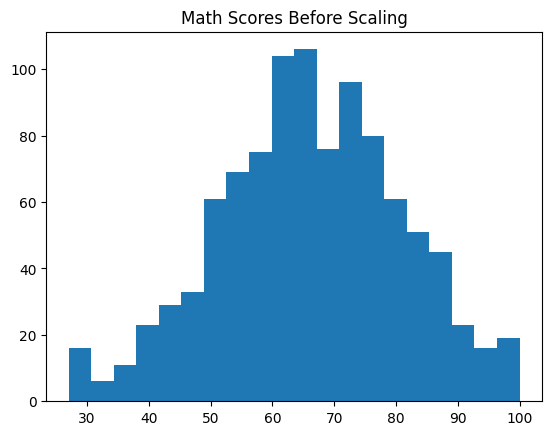

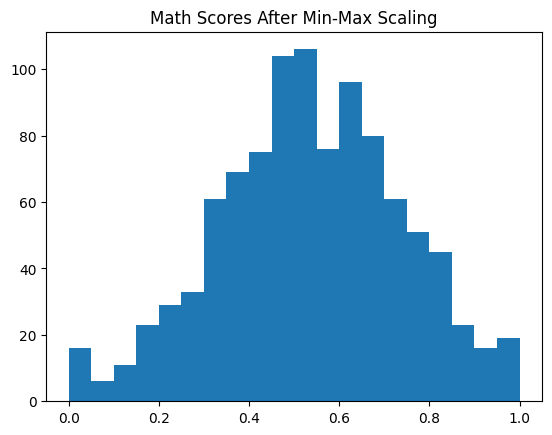

In [ ]:
plt.hist(df["math score"], bins=20)
plt.title("Math Scores Before Scaling")
plt.show()

plt.hist(df["math_scaled"], bins=20)
plt.title("Math Scores After Min-Max Scaling")
plt.show()


In [ ]:
data=df.select_dtypes(include=np.number).skew()

In [ ]:
data

,0
gender,0.072155
math score,-0.148833
reading score,-0.259105
writing score,-0.289444
Science Score,-0.135218
CGPA,-0.168457
math_scaled,-0.148833


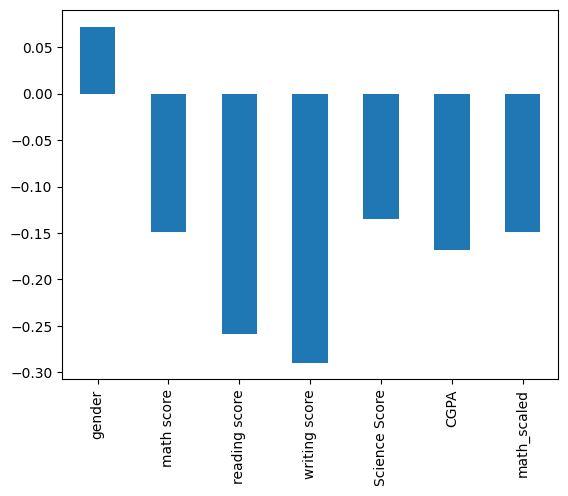

In [ ]:
data.plot(kind="bar")
plt.show()